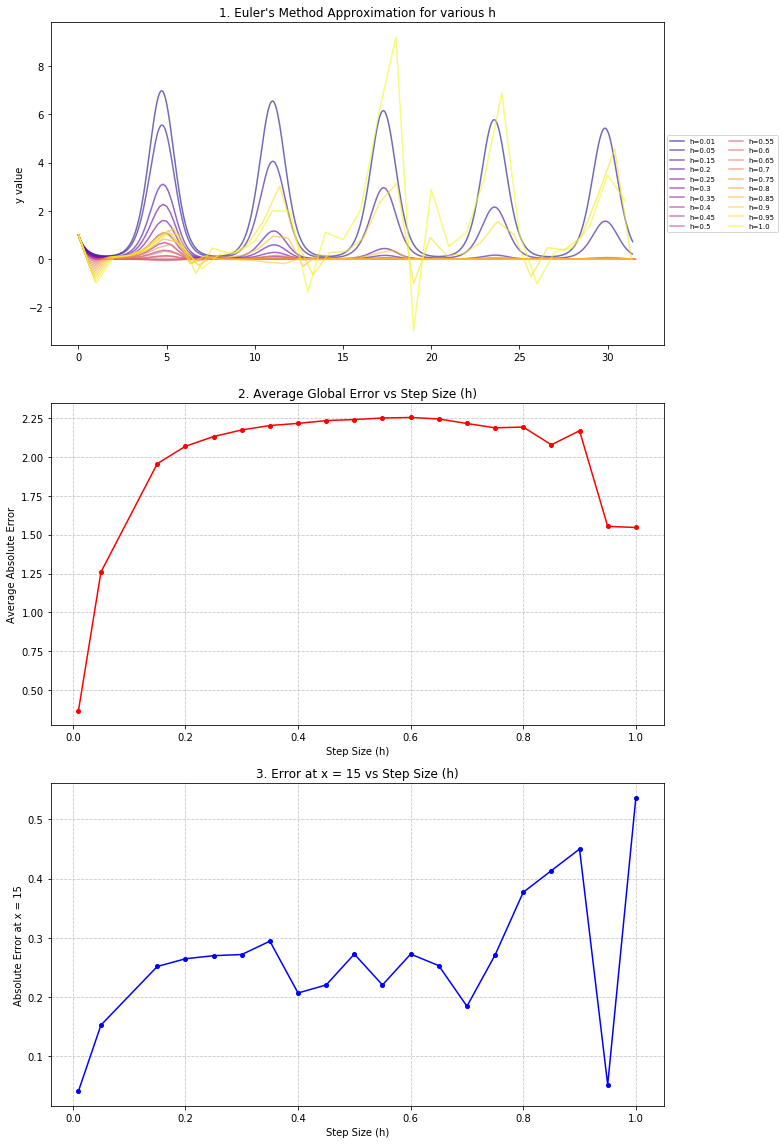

    h |      Avg y |  Avg Error
 0.01 |     1.9104 |     0.3686
 0.05 |     1.0186 |     1.2596
 0.15 |     0.3205 |     1.9558
 0.20 |     0.2046 |     2.0677
 0.25 |     0.1353 |     2.1301
 0.30 |     0.0907 |     2.1725
 0.35 |     0.0603 |     2.2008
 0.40 |     0.0390 |     2.2146
 0.45 |     0.0246 |     2.2324
 0.50 |     0.0156 |     2.2394
 0.55 |     0.0120 |     2.2491
 0.60 |     0.0139 |     2.2527
 0.65 |     0.0217 |     2.2431
 0.70 |     0.0330 |     2.2139
 0.75 |     0.0588 |     2.1861
 0.80 |     0.0685 |     2.1911
 0.85 |     0.1677 |     2.0770
 0.90 |     0.0717 |     2.1674
 0.95 |     0.7898 |     1.5529
 1.00 |     1.3925 |     1.5460


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Setup Parameters
x_start = 0
x_end = 10 * np.pi
# Step sizes: [.01, .05, .15, .2, .25 ... 1.0]
h_values = [0.01, 0.05] + [round(v, 2) for v in np.arange(0.15, 1.05, 0.05)]

def f(x, y):
    return -2 * y * np.cos(x)

def exact_sol(x):
    # analytical solution derived via separation of variables
    return np.exp(-2 * np.sin(x))

# Storage for Analysis
results = {}
avg_y_per_run = []
avg_errors = []
local_errors_at_15 = []

# Computation Loop
for h in h_values:
    # Create x steps ensuring we cover the interval
    x_vals = np.arange(x_start, x_end + h/2, h)
    y_vals = np.zeros(len(x_vals))
    y_vals[0] = 1  # Initial condition y(0) = 1
    
    # Euler's Method Implementation
    for i in range(len(x_vals) - 1):
        y_vals[i+1] = y_vals[i] + h * f(x_vals[i], y_vals[i])
    
    results[h] = (x_vals, y_vals)
    
    # A) Average y values for this run
    avg_y_per_run.append(np.mean(y_vals))
    
    # B) Global Error Analysis (Mean Absolute Error vs Exact)
    y_true = exact_sol(x_vals)
    avg_errors.append(np.mean(np.abs(y_vals - y_true)))
    
    # C) Local Error at x approx 15
    idx_15 = (np.abs(x_vals - 15)).argmin()
    local_errors_at_15.append(np.abs(y_vals[idx_15] - exact_sol(x_vals[idx_15])))

# Plotting
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(11, 16))

# Plot 1: Euler's Method Comparison
colors = plt.cm.plasma(np.linspace(0, 1, len(h_values)))
for i, h in enumerate(h_values):
    x, y = results[h]
    ax1.plot(x, y, color=colors[i], label=f'h={h}', alpha=0.6)
ax1.set_title("1. Euler's Method Approximation for various h")
ax1.set_ylabel("y value")
ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='x-small', ncol=2)

# Plot 2: Average Error vs h
ax2.plot(h_values, avg_errors, 'ro-', linewidth=1.5, markersize=4)
ax2.set_title("2. Average Global Error vs Step Size (h)")
ax2.set_xlabel("Step Size (h)")
ax2.set_ylabel("Average Absolute Error")
ax2.grid(True, linestyle='--', alpha=0.7)

# Plot 3: Error at x = 15 vs h
ax3.plot(h_values, local_errors_at_15, 'bo-', linewidth=1.5, markersize=4)
ax3.set_title("3. Error at x = 15 vs Step Size (h)")
ax3.set_xlabel("Step Size (h)")
ax3.set_ylabel("Absolute Error at x = 15")
ax3.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Print values for summary
print(f"{'h':>5} | {'Avg y':>10} | {'Avg Error':>10}")
for i, h in enumerate(h_values):
    print(f"{h:5.2f} | {avg_y_per_run[i]:10.4f} | {avg_errors[i]:10.4f}")

Stability Condition: The ODE is of the form $y' = \lambda(x)y$ where $\lambda(x) = -2\cos(x)$. For Euler’s method to be stable, we require $|1 + h\lambda| \leq 1$. The "worst-case" for stability occurs when $\cos(x) = 1$, making $\lambda = -2$. This gives the condition $|1 - 2h| \leq 1$, which simplifies to $h \leq 1.0$.Observation of $h$: In the plots, as $h$ increases toward $1.0$, the numerical solution becomes increasingly "jagged." This is because a large $h$ cannot accurately capture the curvature of the exponential function, leading to significant overshoot at each step.Error Growth: Plot 2 shows that the global error grows linearly with $h$. This confirms that Euler's Method is a first-order numerical scheme ($O(h)$).Local vs. Global: The error at $x \approx 15$ (Plot 3) shows how small errors in early steps accumulate over time. Even if $h$ is technically "stable" (e.g., $h=0.8$), the deviation from the exact solution $e^{-2\sin(x)}$ becomes massive because the linear approximation fails to follow the periodic "valleys" of the true solution.